# 15 · Subgraphs — *extra pattern*

**Idea:** A compiled graph can be used as a **node inside another graph**. Build small, testable
graphs (a "team") and snap them together into a bigger one. This is how *hierarchical multi-agent
systems* and reusable workflows are built.

```
PARENT:  START -> write ----> [ editor subgraph: proofread -> tone ] ----> END
```

Two ways to connect a subgraph — pick by whether parent and child **share state keys**:

| Case | How | Section |
|---|---|---|
| Parent & child share at least one key | `parent.add_node("name", child_graph)` — directly | A |
| Different state schemas | Call the child **inside a wrapper function** and map the data in/out | B |

Then: see inside with streaming (C), and pause for a human inside a subgraph (D).

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

## A · Shared state keys → add the compiled subgraph directly as a node

The child has its own state (`EditorState`) with a **private** key `notes`.
It shares the key `draft` with the parent, so `draft` flows in and the edited `draft` flows back out.
`notes` stays inside the child — the parent never sees it.

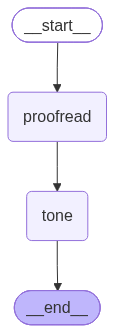

In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------- CHILD graph (the "editor team") ----------
class EditorState(TypedDict):
    draft: str      # shared with parent
    notes: str      # PRIVATE to the child

def proofread(state: EditorState):
    fixed = small_llm.invoke(f"Fix spelling and grammar. Return only the text:\n{state['draft']}").content
    return {"draft": fixed, "notes": "proofread done"}

def tone(state: EditorState):
    friendly = small_llm.invoke(f"Rewrite in a warm, friendly tone. Return only the text:\n{state['draft']}").content
    return {"draft": friendly, "notes": state["notes"] + ", tone done"}

child = StateGraph(EditorState)
child.add_node("proofread", proofread)
child.add_node("tone", tone)
child.add_edge(START, "proofread")
child.add_edge("proofread", "tone")
child.add_edge("tone", END)
editor_graph = child.compile()          # <- a normal compiled graph; you can test it on its own!

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(editor_graph.get_graph().draw_mermaid_png()))


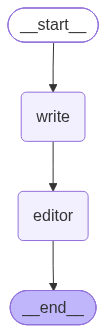

In [8]:
# ---------- PARENT graph ----------
class ParentState(TypedDict):
    topic: str
    draft: str       # same key name as in EditorState -> that's the "bridge"

def write(state: ParentState):
    return {"draft": llm.invoke(f"Write a 2-sentence announcement about: {state['topic']}").content}

parent = StateGraph(ParentState)
parent.add_node("write", write)
parent.add_node("editor", editor_graph)       # <- the subgraph IS the node
parent.add_edge(START, "write")
parent.add_edge("write", "editor")
parent.add_edge("editor", END)
graph = parent.compile()

from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))



In [9]:
out = graph.invoke({"topic": "our office moving to a new building"})
print(out["draft"])
print("keys visible to parent:", list(out))   # note: no 'notes' - it stayed private to the child

Here is a 2-sentence announcement about the office move:  
We are excited to announce that our office will be relocating to a new building, effective [insert date], where we will have more space and improved amenities to better serve our clients and employees. Our new address will be [insert new address], and we will be in touch with all clients and stakeholders to ensure a smooth transition to our new location.
keys visible to parent: ['topic', 'draft']


## B · Different state schemas → call the subgraph from a wrapper node

Here the child (`FactCheckState`) uses totally different key names, so we **translate** at the boundary:
parent state → child input → child output → parent state. More code, but total isolation.

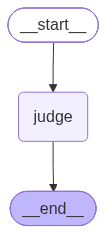

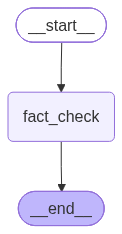

Yes, the claim is plausible. The Moon orbits the Earth approximately once every 27 to 30 days.


In [12]:
class FactCheckState(TypedDict):
    claim: str
    verdict: str

def judge(state: FactCheckState):
    v = small_llm.invoke(f"Is this claim plausible? Answer in one short sentence.\nClaim: {state['claim']}").content
    return {"verdict": v}

fc = StateGraph(FactCheckState)
fc.add_node("judge", judge)
fc.add_edge(START, "judge")
fc.add_edge("judge", END)
fact_checker = fc.compile()

# ---- parent with DIFFERENT keys ----
class ReportState(TypedDict):
    statement: str
    check_result: str

def run_fact_check(state: ReportState):
    child_out = fact_checker.invoke({"claim": state["statement"]})      # parent -> child  (rename key)
    return {"check_result": child_out["verdict"]}                       # child -> parent  (rename key)

rep = StateGraph(ReportState)
rep.add_node("fact_check", run_fact_check)
rep.add_edge(START, "fact_check")
rep.add_edge("fact_check", END)
report_graph = rep.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(fact_checker.get_graph().draw_mermaid_png()))
display(Image(report_graph.get_graph().draw_mermaid_png()))
print(report_graph.invoke({"statement": "The Moon orbits the Earth about once a month."})["check_result"])

## C · Seeing inside the subgraph (streaming)

By default you only see the parent's steps. Pass `subgraphs=True` and every update arrives as
`(namespace, update)`. An empty namespace `()` = the parent; `("editor:<id>",)` = inside the `editor` subgraph.

In [13]:
for namespace, update in graph.stream({"topic": "a new cafeteria menu"}, stream_mode="updates", subgraphs=True):
    where = "PARENT" if not namespace else "inside " + namespace[0].split(":")[0]
    for node_name in update:
        print(f"{where:>16} -> {node_name}")

          PARENT -> write
   inside editor -> proofread
   inside editor -> tone
          PARENT -> editor


## D · Human-in-the-loop *inside* a subgraph

`interrupt()` works at any depth. Only the **parent** needs the checkpointer (the child inherits it).
When resumed, the paused subgraph continues where it stopped, then control returns to the parent.

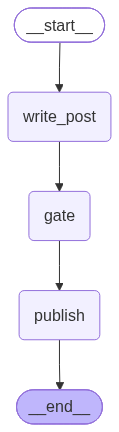

⏸️  paused inside subgraph: {'question': 'Publish this?', 'draft': '"🎉 Open-source release! 🌟 Let\'s build something together."'}
📣 PUBLISHED: "🎉 Open-source release! 🌟 Let's build something together."


In [15]:
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

# ---- child: a tiny "approval gate" team ----
class GateState(TypedDict):
    draft: str
    approved: bool

def ask_human(state: GateState):
    ok = interrupt({"question": "Publish this?", "draft": state["draft"]})   # pauses the WHOLE run
    return {"approved": ok}

g = StateGraph(GateState)
g.add_node("ask_human", ask_human)
g.add_edge(START, "ask_human")
g.add_edge("ask_human", END)
gate_graph = g.compile()                  # NOTE: no checkpointer here

# ---- parent ----
class PubState(TypedDict):
    topic: str
    draft: str
    approved: bool
    result: str

def write_post(state: PubState):
    return {"draft": small_llm.invoke(f"Write a one-line social post about {state['topic']}").content}

def publish(state: PubState):
    return {"result": "📣 PUBLISHED: " + state["draft"] if state["approved"] else "🛑 Not published."}

p = StateGraph(PubState)
p.add_node("write_post", write_post)
p.add_node("gate", gate_graph)            # subgraph as a node
p.add_node("publish", publish)
p.add_edge(START, "write_post")
p.add_edge("write_post", "gate")
p.add_edge("gate", "publish")
p.add_edge("publish", END)
pub_graph = p.compile(checkpointer=InMemorySaver())      # checkpointer on the PARENT only
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(pub_graph.get_graph().draw_mermaid_png()))
cfg = {"configurable": {"thread_id": "pub-1"}}
r = pub_graph.invoke({"topic": "our open-source release"}, cfg)
print("⏸️  paused inside subgraph:", r["__interrupt__"][0].value)

r = pub_graph.invoke(Command(resume=True), cfg)           # human says yes
print(r["result"])

### When to use subgraphs
* **Reuse** – the same "editor" team plugged into many workflows.
* **Team ownership** – each team develops/tests its own graph; only the shared keys are the contract.
* **Hierarchical agents** – a supervisor (notebook 04) whose workers are themselves supervisors with their own workers.
* **Isolation** – private state keys and internal loops stay out of the parent's way.

Tip: give each subgraph a clear, small interface (the shared keys), and test it standalone with `editor_graph.invoke(...)` first.